# Insurance Premium Prediction

**Author:** Lim Ming Jun

**Notebook 02 — EDA and Preprocessing.** Explores the consolidated dataset, then cleans it and
writes `cleaned_data.csv`.

# 2 Exploratory Data Analysis (EDA)

## 2.1 Setup

Charts use plotly with the `notebook_connected` renderer. The chart library is loaded from a CDN
instead of being written into this file, which keeps the notebook small. Switch the renderer to
`notebook` if you need the charts to work without internet access.

`PROJECT_ROOT` is resolved by walking up to the directory containing `pyproject.toml`, so the
paths hold regardless of the kernel's working directory.

In [41]:
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import sweetviz as sv
from scipy import stats
from IPython.display import Markdown, display

# Load the plotly library from a CDN. Swap the lines below for offline use.
pio.renderers.default = "notebook_connected"
# pio.renderers.default = "notebook"

PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())
DATA_DIR = PROJECT_ROOT / "data"

TARGET = "charges"

print(f"Project root : {PROJECT_ROOT}")
print(f"Data folder  : {DATA_DIR}")

Project root : c:\Users\ILLEGEAR\OneDrive\Desktop\Personal Project\DS & ML\Insurance Premium Prediction
Data folder  : c:\Users\ILLEGEAR\OneDrive\Desktop\Personal Project\DS & ML\Insurance Premium Prediction\data


In [42]:
# Load the canonical dataset written by notebook 01
df = pd.read_csv(DATA_DIR / "merged_data.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2.2 Data Overview

### 2.2.1 Data Shape

In [43]:
print("Dataset shape")
print("-----------------------------------------")
print("Rows     : ", df.shape[0])
print("Columns  : ", df.shape[1])
print("Shape    : ", df.shape)
print("Features : \n", df.columns.tolist())

Dataset shape
-----------------------------------------
Rows     :  1338
Columns  :  7
Shape    :  (1338, 7)
Features : 
 ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


### 2.2.2 Data Info

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


### 2.2.3 Data Unique Values

`summarise_features()` reports the dtype, the unique count and the unique values of every column.
It is called once here, and once again after the dtype conversion below.

In [45]:
MAX_UNIQUE_TO_LIST = 15


def summarise_features(data, max_unique=MAX_UNIQUE_TO_LIST):
    """Report the dtype, unique count and unique values of every column."""
    rows = []
    for col in data.columns:
        n_unique = data[col].nunique()
        rows.append({
            "Feature": col,
            "Data Type": data[col].dtype,
            "Number of Unique Values": n_unique,
            "Unique Values": list(data[col].unique())
            if n_unique <= max_unique
            else f"more than {max_unique} unique values",
        })
    return (
        pd.DataFrame(rows)
        .sort_values("Number of Unique Values", ascending=False)
        .reset_index(drop=True)
    )


display(Markdown("#### Data type and unique values of each feature:"))
with pd.option_context("display.max_colwidth", None):
    display(summarise_features(df))

#### Data type and unique values of each feature:

,Feature,Data Type,Number of Unique Values,Unique Values
0,charges,float64,1337,more than 15 unique values
1,bmi,float64,548,more than 15 unique values
2,age,int64,47,more than 15 unique values
3,children,int64,6,"[0, 1, 3, 2, 5, 4]"
4,region,str,4,"[southwest, southeast, northwest, northeast]"
5,sex,str,2,"[female, male]"
6,smoker,str,2,"[yes, no]"


After reviewing the result from the cell above, as well as the sample data of the dataset and
the data dictionary, I decided to convert these columns:

- **`region`**
- **`sex`**
- **`smoker`**

from **`str`** data type to **`category`** data type. Each holds a small, fixed set of labels, so
`category` states that intent and uses less memory.

One consequence: `category` columns are **not** matched by `select_dtypes(include="object")`. The
rest of this notebook selects them with `include="category"`, and calls `describe(include="all")`
so that they still appear in the summary statistics.

In [46]:
# Convert the low-cardinality text columns to the "category" dtype
for col in ["region", "sex", "smoker"]:
    df[col] = df[col].astype("category")
    print(f"'{col}' data type has been converted to 'category' type.")

'region' data type has been converted to 'category' type.
'sex' data type has been converted to 'category' type.
'smoker' data type has been converted to 'category' type.


In [47]:
display(Markdown("#### Data type and unique values of each feature (updated):"))
with pd.option_context("display.max_colwidth", None):
    display(summarise_features(df))

#### Data type and unique values of each feature (updated):

,Feature,Data Type,Number of Unique Values,Unique Values
0,charges,float64,1337,more than 15 unique values
1,bmi,float64,548,more than 15 unique values
2,age,int64,47,more than 15 unique values
3,children,int64,6,"[0, 1, 3, 2, 5, 4]"
4,region,category,4,"[southwest, southeast, northwest, northeast]"
5,sex,category,2,"[female, male]"
6,smoker,category,2,"[yes, no]"


### 2.2.4 Data Summary Statistic

In [48]:
# include="all" is required, because plain describe() hides the category columns
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


### 2.2.5 Understanding Data Distribution

The target is continuous, so the distribution of `charges` replaces the class-balance chart that a
classification project would show here.

In [49]:
fig = px.histogram(df, x=TARGET, nbins=50, marginal="box", title=f"Distribution of {TARGET}")
fig.update_layout(title_x=0.5, bargap=0.05)
fig.show()

print(f"skew   : {df[TARGET].skew():.2f}")
print(f"mean   : {df[TARGET].mean():,.2f}")
print(f"median : {df[TARGET].median():,.2f}")

skew   : 1.52
mean   : 13,270.42
median : 9,382.03


### 2.2.6 Understanding Missing Values

The table lists **every** column, not only the ones with a problem. A table of zeros proves that
all columns were inspected. An empty table would prove nothing.

In [50]:
def detect_missing_values(data):
    """Report the missing count and percentage of every column."""
    count = data.isnull().sum()
    percentage = count / len(data) * 100
    return (
        pd.concat([count, percentage], axis=1, keys=["Count", "Percentage (%)"])
        .rename_axis("Features")
        .sort_values("Count", ascending=False)
        .reset_index()
    )


display(Markdown("#### Count and percentage of missing values for the columns:"))
display(detect_missing_values(df))

missing_rows = int(df.isnull().any(axis=1).sum())
display(Markdown(f"**Total missing values: {int(df.isnull().sum().sum())}**"))
display(Markdown(f"**Total rows with missing values: {missing_rows}**"))
display(Markdown(f"**Percentage of rows with missing values: {missing_rows / len(df) * 100:.2f}%**"))

#### Count and percentage of missing values for the columns:

,Features,Count,Percentage (%)
0,age,0,0.0
1,sex,0,0.0
2,bmi,0,0.0
3,children,0,0.0
4,smoker,0,0.0
5,region,0,0.0
6,charges,0,0.0


**Total missing values: 0**

**Total rows with missing values: 0**

**Percentage of rows with missing values: 0.00%**

### 2.2.7 Overall Insights of EDA using AutoEDA

`sweetviz` profiles every column and ranks each one by its association with the target. It runs
against the current `numpy` version with no library patch.

Feature: charges (TARGET)                    |█▎        | [ 12%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: age                                 |██▌       | [ 25%]   00:01 -> (00:04 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal,


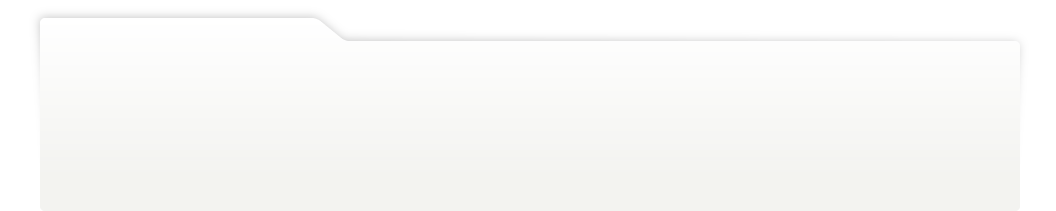
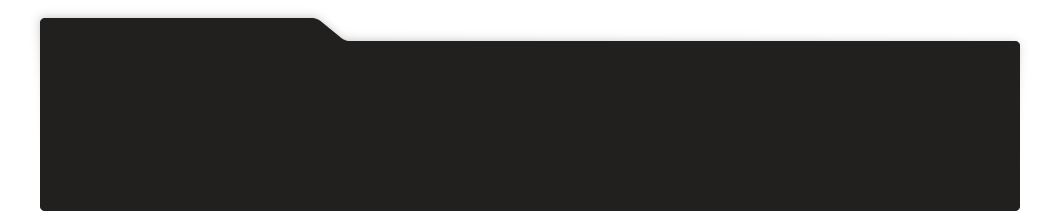
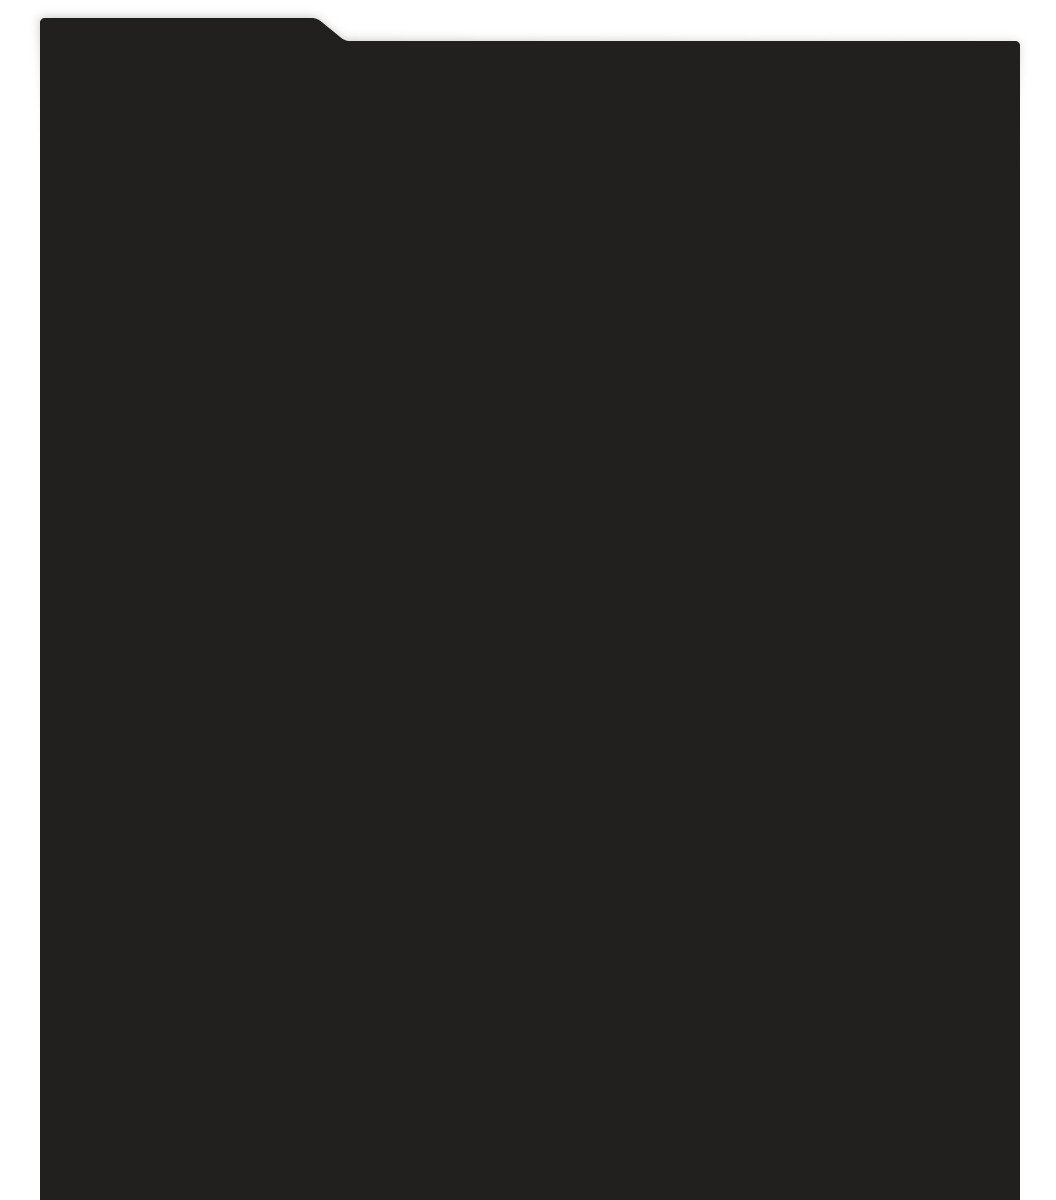
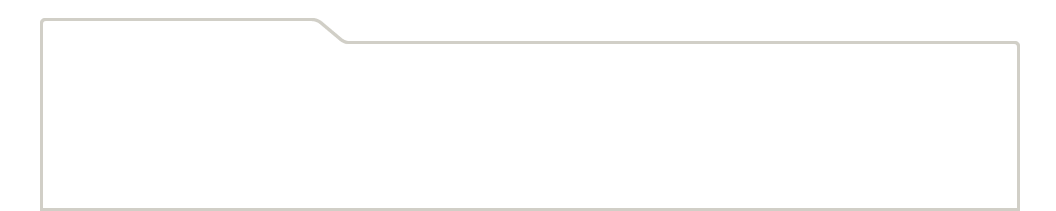
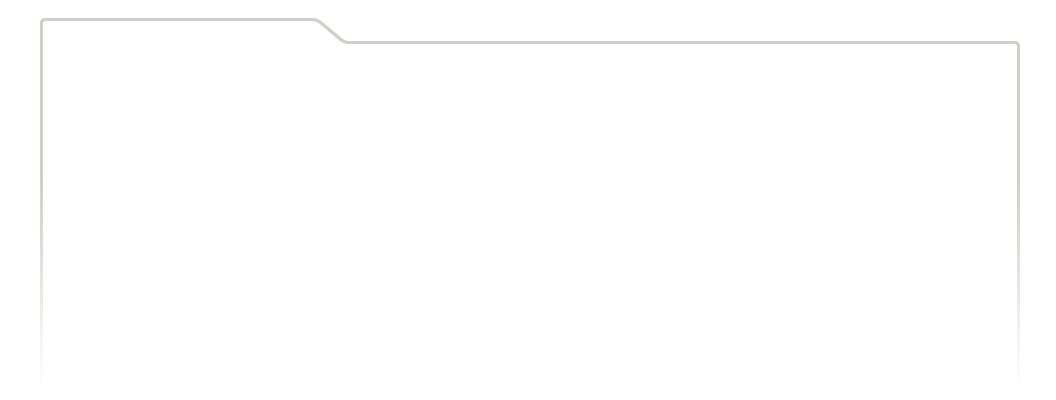
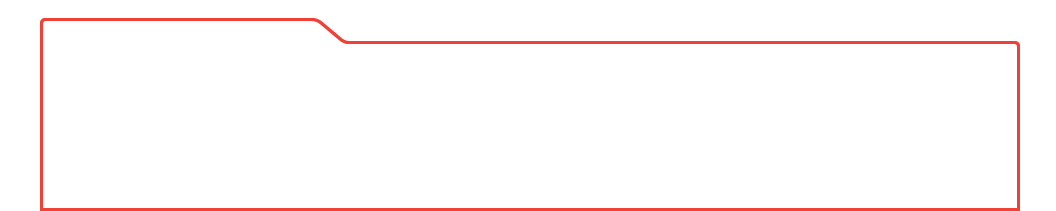
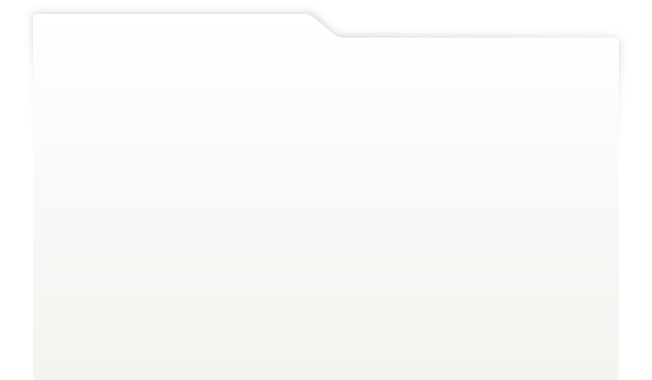
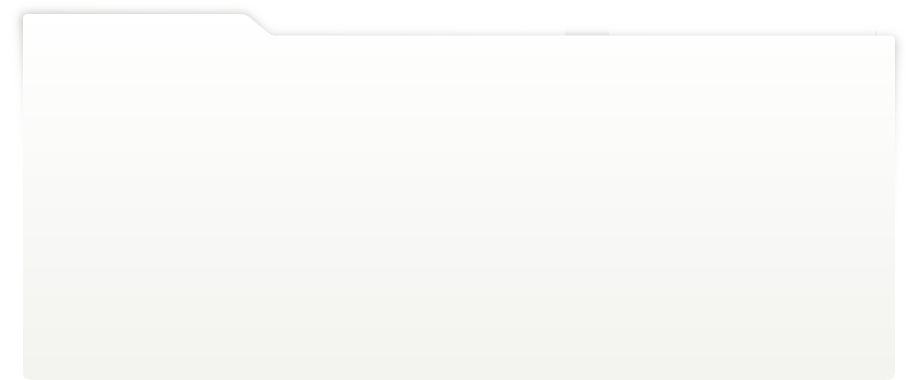
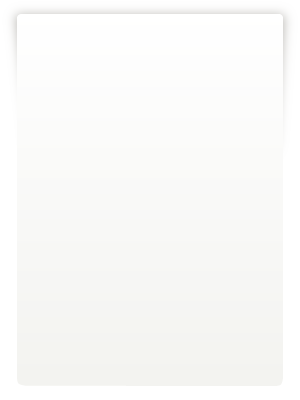
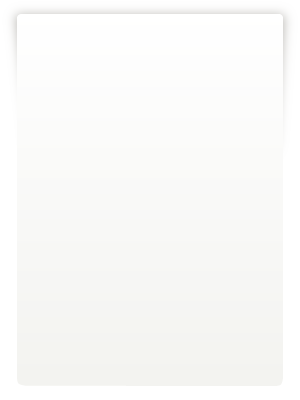
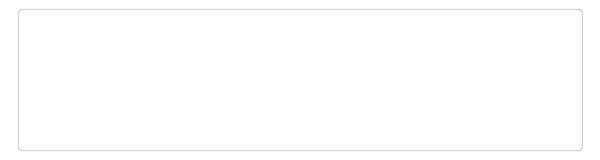
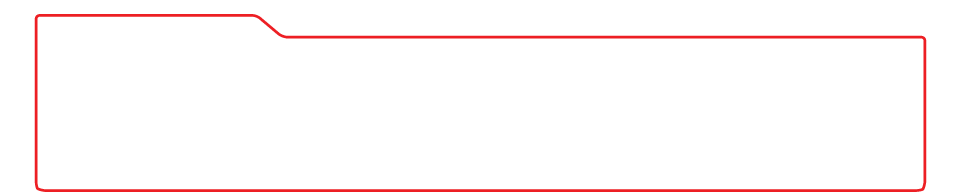
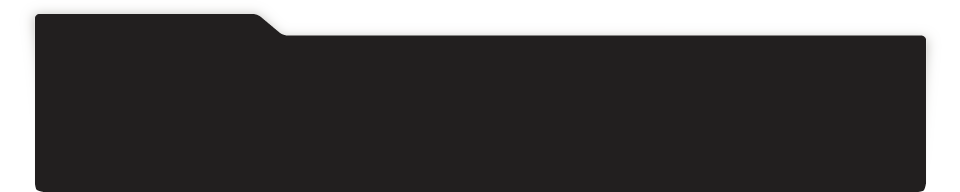
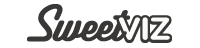
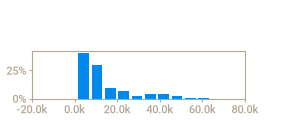
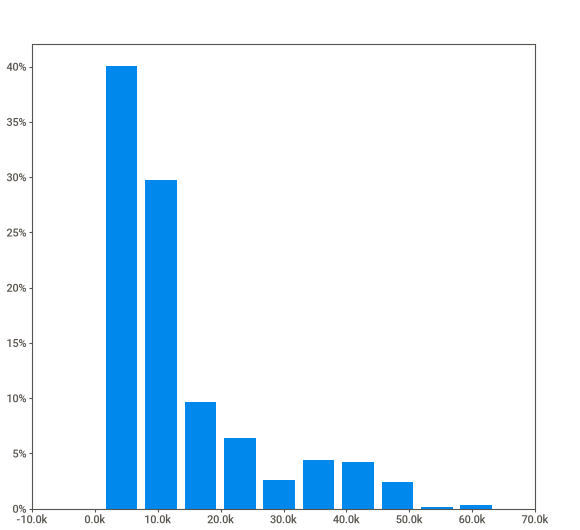
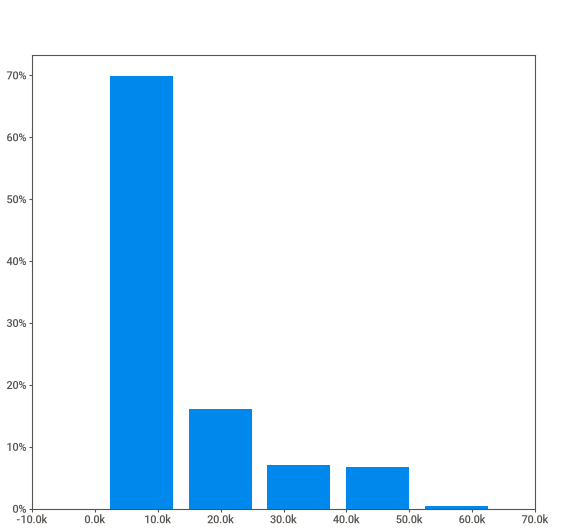
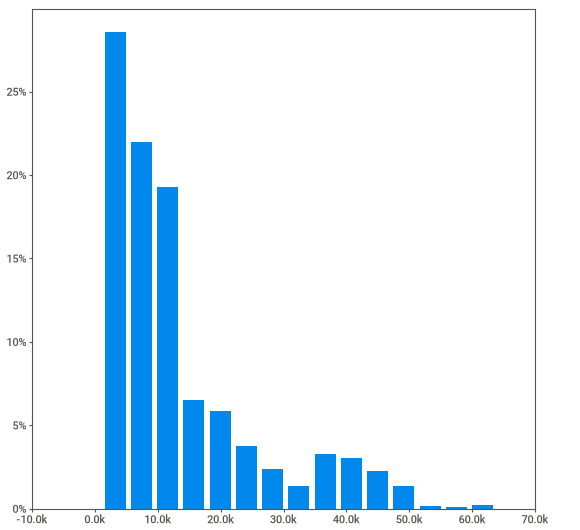
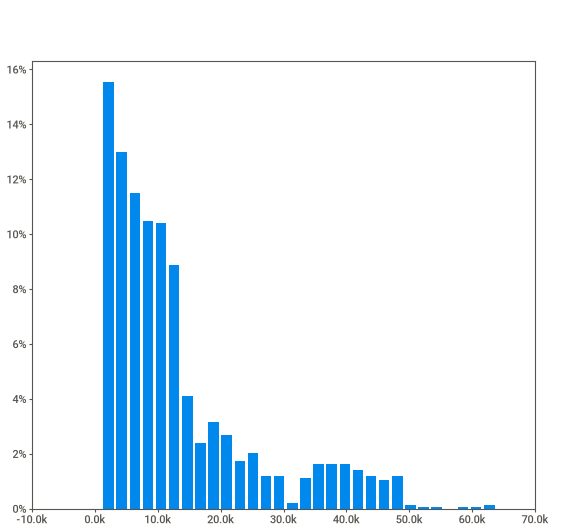
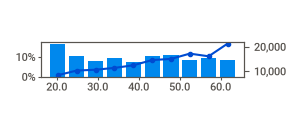
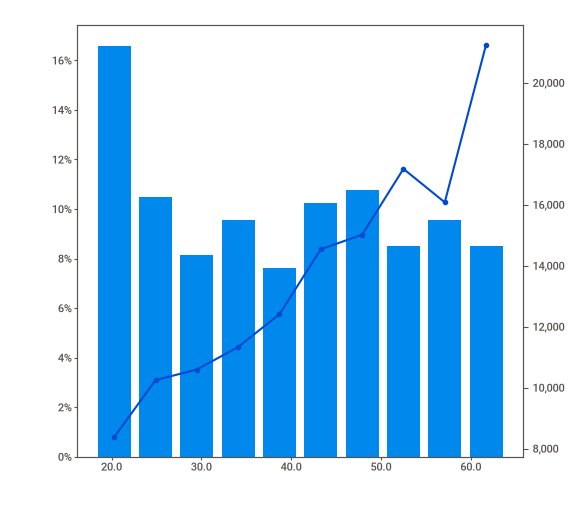
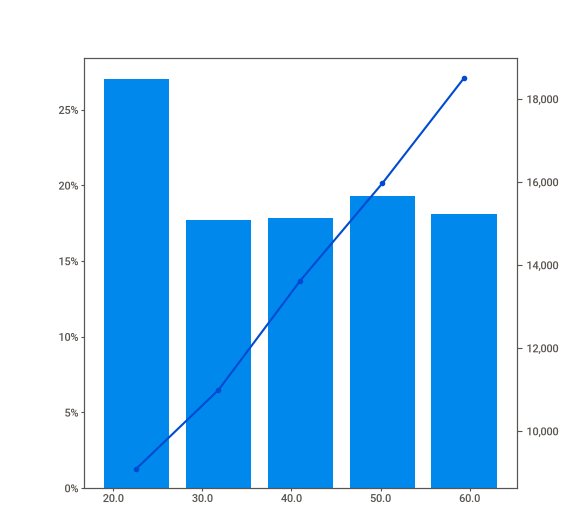
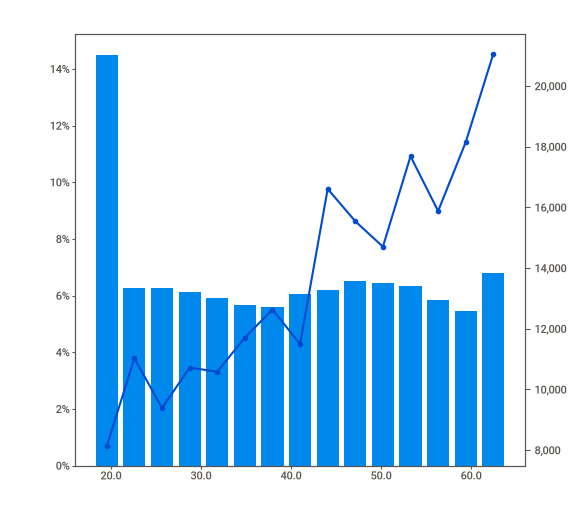
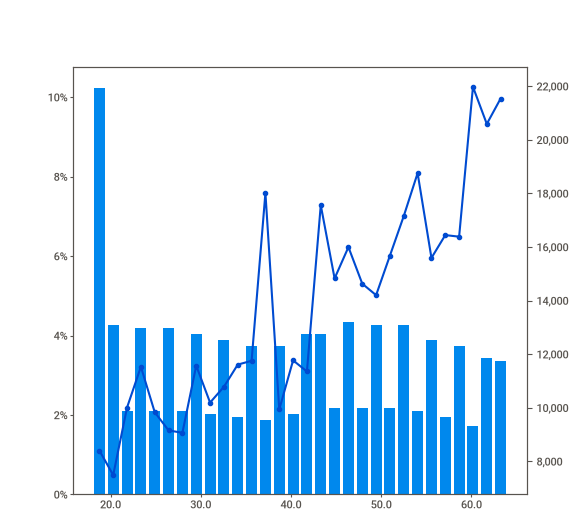
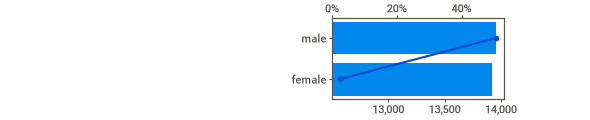
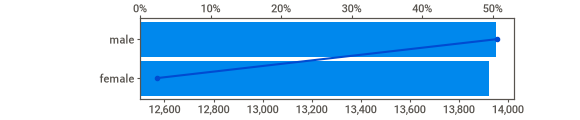
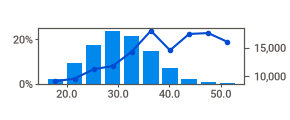
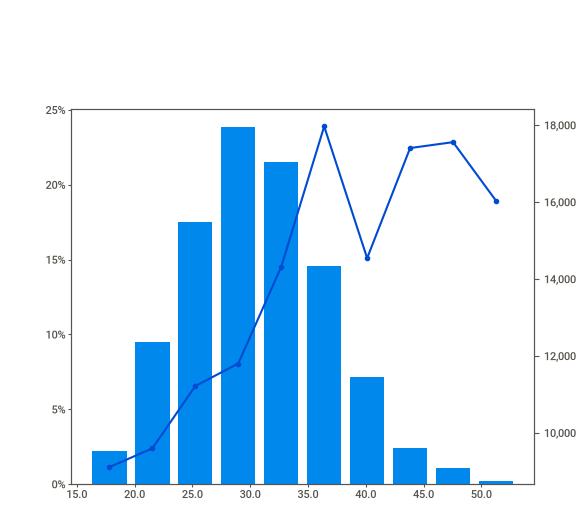
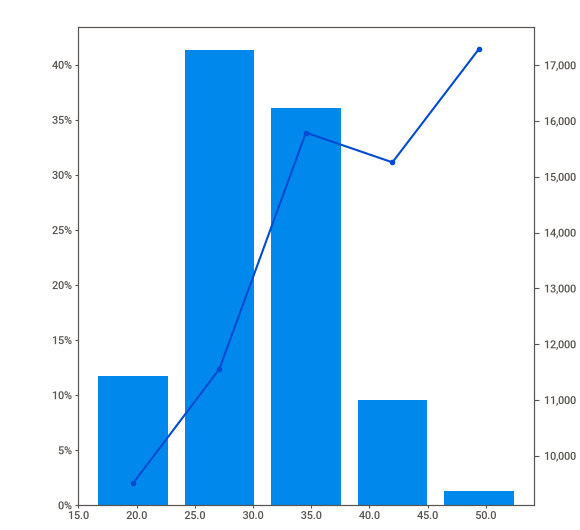
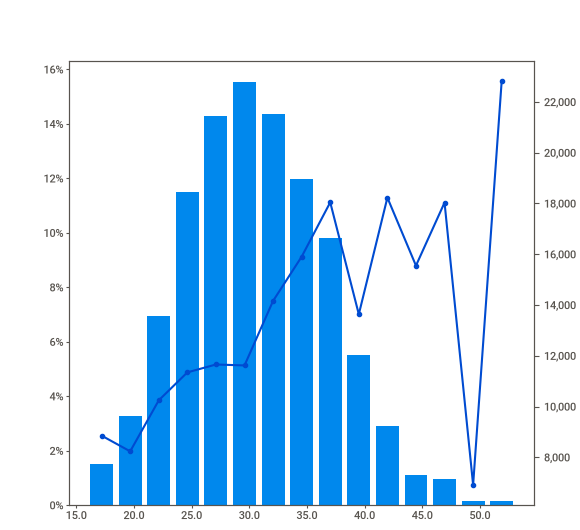
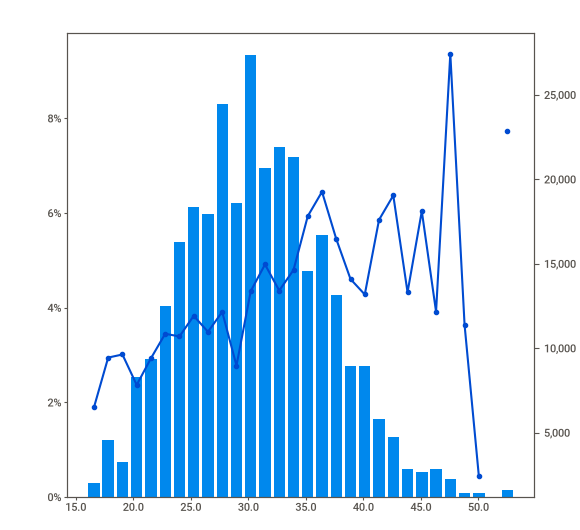
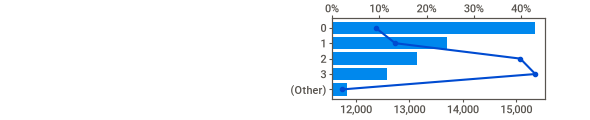
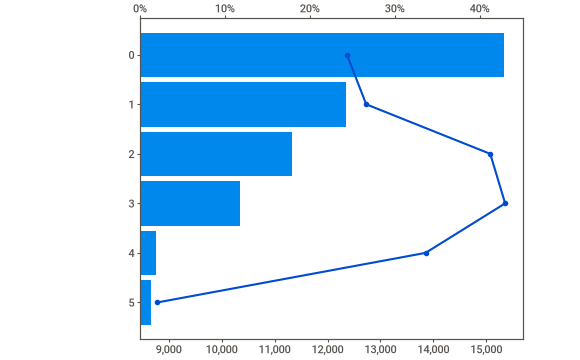
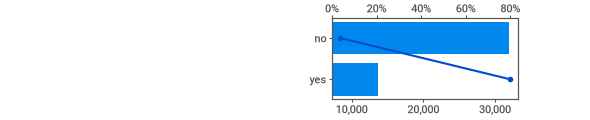
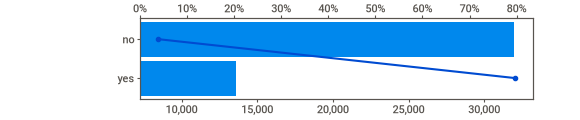
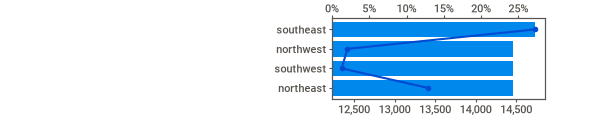
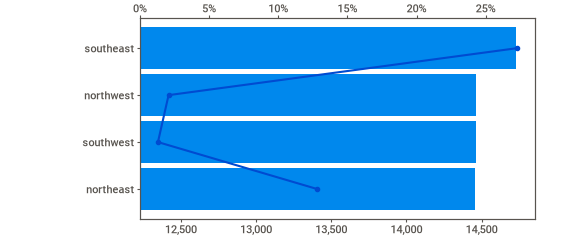
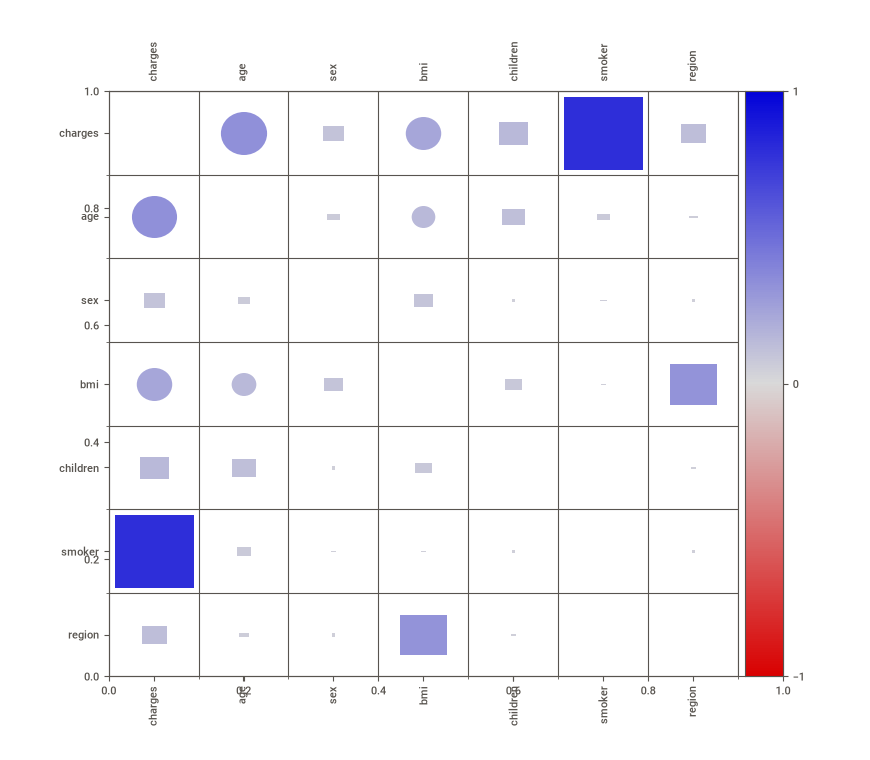
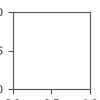

In [51]:
# Using sweetviz to generate the report
sweet_report = sv.analyze(source=df, target_feat=TARGET)
sweet_report.show_notebook(w="100%", h="Full", layout="vertical")

### 2.2.8 Categorical Variable vs Target Variable (charges)

The target is a number, not a class, so a box plot per category replaces the stacked percentage
bars used by a classification project. The box shows how the whole distribution of `charges`
shifts between the categories.

In [52]:
for cat_col in df.select_dtypes(include="category").columns:
    fig = px.box(
        df, 
        x=cat_col, 
        y=TARGET, 
        color=cat_col, 
        title=f"{TARGET} by {cat_col}"
    )
    fig.update_layout(title_x=0.5, showlegend=False)
    fig.show()

### 2.2.9 Continuous Variable vs Target Variable (charges)

A scatter plot replaces the overlaid per-class histograms. Points are coloured by `smoker`,
because that feature separates the data most strongly.

In [53]:
for con_col in df.select_dtypes(include="number").columns.drop(TARGET):
    fig = px.scatter(
        df, x=con_col, 
        y=TARGET, 
        color="smoker", 
        opacity=0.6,
        title=f"{TARGET} against {con_col}"
    )
    fig.update_layout(title_x=0.5)
    fig.show()

# 3 Data Preparation

## 3.1 Selecting Data

**Selecting items (rows):** All 1,338 rows are kept, except duplicated rows. In particular, the
high-cost beneficiaries are **kept**. An interquartile-range rule would classify 139 of them as
outliers and delete 10.8% of the dataset, including half of all smokers. Those rows are not
recording errors. They are the exact pattern the model must learn, so removing them would remove
the signal. Section 3.2.3 records this decision against the box plots.

**Selecting attributes (columns):** All 7 columns are kept. None is constant, none has high
cardinality, and no pair of features is strongly correlated. Sections 3.2.2 and 3.2.5 show the
checks that support this.

## 3.2 Data Cleaning

Each subsection follows the same four-step rhythm: **analyse** the relevant diagnostic, **identify**
what meets the removal or transformation criteria, **apply** the cleaning rule only where necessary,
then **validate** the result. The handler code always runs, so the notebook stays correct if the
input data changes later — on this dataset most checks find nothing to remove, and the tables of
zeros are the expected output on clean data.

Each threshold used below is defined in the subsection that uses it, next to the logic it governs.

### 3.2.1 Remove Missing Values

**Why it matters.** A model cannot train on empty cells, and an invented target value would be a
false label. Missingness left unhandled either crashes training or silently biases the model.

**How it is identified.** The table below repeats the missing-value check from 2.2.6, this time
immediately before the fix: every column is listed with its missing count and percentage.

**How it is handled.** Three stages:

1. **Drop a column** that is more than `MISSING_COLUMN_DROP_SHARE` empty. Too little of it is left
   to be useful.
2. **Fill the rest.** A numeric column is filled by sampling its own distribution with Kernel
   Density Estimation, which keeps the shape and the skew of the column — a mean or median fill
   would push a spike onto one value and reduce the variance. A categorical column is filled with
   its most common value.
3. **Drop any row that is still incomplete.** After stage 2 this means the target itself is
   missing, and such a row cannot teach the model anything.

The target column is never imputed.

**Workflow.**

1. Display the count and percentage of missing values for every column.
2. Flag columns above `MISSING_COLUMN_DROP_SHARE`, and any remaining incomplete rows.
3. Apply the three-stage handler only where the diagnostic found gaps.
4. Re-run the same table and report the shape to confirm nothing is missing.

In [54]:
# A column that is more than this share empty is dropped rather than imputed
MISSING_COLUMN_DROP_SHARE = 0.5


def impute_numeric_by_kde(data, column, random_state=42):
    """Fill missing values by sampling the column's own distribution."""
    known = data[column].dropna()
    n_missing = int(data[column].isna().sum())

    if known.nunique() < 2:
        data.loc[data[column].isna(), column] = known.median() if len(known) else 0
        return "median (too few distinct values for KDE)"

    kde = stats.gaussian_kde(known)
    data.loc[data[column].isna(), column] = kde.resample(size=n_missing, seed=random_state)[0]
    return "KDE sampling"


# Analyse: show the missing-value profile of every column before any fix
display(Markdown("#### Count and percentage of missing values, before cleaning:"))
display(detect_missing_values(df))

total_missing = int(df.isnull().sum().sum())
print(f"Missing values in the dataset: {total_missing}")

if total_missing == 0:
    print("Result: no imputation and no row removal are required.")
else:
    # Stage 1: identify and drop the columns that are mostly empty
    share = df.isnull().mean()
    mostly_empty = [c for c in share[share > MISSING_COLUMN_DROP_SHARE].index if c != TARGET]
    if mostly_empty:
        df = df.drop(columns=mostly_empty)
        print(f"Dropped mostly-empty columns: {mostly_empty}")

    # Stage 2: fill what remains, by dtype (KDE for numeric, mode for categorical)
    for col in [c for c in df.columns[df.isnull().any()] if c != TARGET]:
        if pd.api.types.is_numeric_dtype(df[col]):
            how = impute_numeric_by_kde(df, col)
        else:
            df[col] = df[col].fillna(df[col].mode().iloc[0])
            how = "mode"
        print(f"Imputed '{col}' using {how}.")

    # Stage 3: drop any row that is still incomplete (only the target can be missing now)
    still_incomplete = int(df.isnull().any(axis=1).sum())
    if still_incomplete:
        df = df.dropna(axis=0, ignore_index=True)
        print(f"Dropped {still_incomplete} rows that were still incomplete.")

    # Validate: the same table must now read zero everywhere
    display(Markdown("#### Count and percentage of missing values, after cleaning:"))
    display(detect_missing_values(df))
    print(f"Result: {int(df.isnull().sum().sum())} missing values remain. Shape: {df.shape}")

#### Count and percentage of missing values, before cleaning:

,Features,Count,Percentage (%)
0,age,0,0.0
1,sex,0,0.0
2,bmi,0,0.0
3,children,0,0.0
4,smoker,0,0.0
5,region,0,0.0
6,charges,0,0.0


Missing values in the dataset: 0
Result: no imputation and no row removal are required.


### 3.2.2 Remove Constant & Low Variance Features

**Why it matters.** A feature that barely varies gives a model almost no information, yet it still
adds a coefficient to fit and noise to interpret.

**How it is identified.** Two diagnostic tables report, for every column, its most common value
(the mode), the share of rows it covers, and its distinct-value count:

- **Constant feature:** only 1 distinct value.
- **Low variance feature:** one value covers a very large share of the rows.

**How it is handled.** The two feature types use different limits because categorical labels are
naturally concentrated: a continuous feature is dropped at `LOW_VARIANCE_NUMERIC` (90%), a
categorical feature at `LOW_VARIANCE_CATEGORICAL` (95%). The target is never dropped, whatever its
distribution looks like.

**Workflow.**

1. Display the mode-share table for every numeric column and every categorical column.
2. Flag columns that are constant or above their type's threshold.
3. Drop the flagged columns, excluding the target.
4. Report which columns were dropped and the resulting shape.

In [55]:
# One value covering this share of the rows makes a feature useless to a model
LOW_VARIANCE_NUMERIC = 90.0        # limit for continuous features
LOW_VARIANCE_CATEGORICAL = 95.0    # limit for categorical features


def create_mode_df(data, columns, label, threshold):
    """Report the most common value of every column, and how much of the data it covers."""
    rows = []
    for col in columns:
        # Measure the dominant value and the share of rows it occupies
        counts = data[col].value_counts()
        rows.append({
            label: col,
            "Mode Value": counts.index[0],
            "Frequency": int(counts.iloc[0]),
            "Percentage (%)": round(counts.iloc[0] / len(data) * 100, 2),
            "Unique Values": int(data[col].nunique()),
        })
    table = pd.DataFrame(rows).sort_values("Percentage (%)", ascending=False)
    table["Above Threshold"] = table["Percentage (%)"] >= threshold
    return table.reset_index(drop=True)


numeric_cols = df.select_dtypes(include="number").columns.tolist()
category_cols = df.select_dtypes(include="category").columns.tolist()

display(Markdown(f"### Total Rows: {len(df)}"))

# Analyse: mode share of every continuous feature, flagged at the numeric limit
concen_df = create_mode_df(df, numeric_cols, "Continuous Features", LOW_VARIANCE_NUMERIC)
display(Markdown(f"#### Continuous features (dropped at {LOW_VARIANCE_NUMERIC:.0f}%):"))
display(concen_df)

# Analyse: the same view for categorical features, flagged at the higher limit
mode_df = create_mode_df(df, category_cols, "Categorical Features", LOW_VARIANCE_CATEGORICAL)
display(Markdown(f"#### Categorical features (dropped at {LOW_VARIANCE_CATEGORICAL:.0f}%):"))
display(mode_df)

# Identify: a feature is useless if it holds one value, or if one value dominates it
constant = (
    concen_df.loc[concen_df["Unique Values"] == 1, "Continuous Features"].tolist()
    + mode_df.loc[mode_df["Unique Values"] == 1, "Categorical Features"].tolist()
)
low_variance = (
    concen_df.loc[concen_df["Above Threshold"], "Continuous Features"].tolist()
    + mode_df.loc[mode_df["Above Threshold"], "Categorical Features"].tolist()
)

print(f"Constant features     : {constant or 'none'}")
print(f"Low variance features : {low_variance or 'none'}")

# Apply: drop the flagged columns, never the target. dict.fromkeys de-duplicates in order.
drop_cols = [c for c in dict.fromkeys(constant + low_variance) if c != TARGET]

# Validate: report what left the dataset, and the resulting shape
if drop_cols:
    df = df.drop(columns=drop_cols)
    print(f"Result: dropped {drop_cols}. Shape: {df.shape}")
else:
    print("Result: no column is dropped.")

### Total Rows: 1338

#### Continuous features (dropped at 90%):

,Continuous Features,Mode Value,Frequency,Percentage (%),Unique Values,Above Threshold
0,children,0.0000,574,42.90,6,False
1,age,18.0000,69,5.16,47,False
2,bmi,32.3000,13,0.97,548,False
3,charges,1639.5631,2,0.15,1337,False


#### Categorical features (dropped at 95%):

,Categorical Features,Mode Value,Frequency,Percentage (%),Unique Values,Above Threshold
0,smoker,no,1064,79.52,2,False
1,sex,male,676,50.52,2,False
2,region,southeast,364,27.20,4,False


Constant features     : none
Low variance features : none
Result: no column is dropped.


### 3.2.3 Remove Outliers

**Why it matters.** Extreme values can be genuine signal or recording errors. Deleting the genuine
ones makes the training data cheaper than reality, and the model would under-predict exactly the
cases that matter most.

**How it is identified.** The box plots below show the spread of each numeric feature. Points
beyond the whiskers are the candidates an interquartile-range rule would delete.

**How it is handled — decision: no outlier is removed.**

The `charges` box plot shows a long upper tail. An interquartile-range rule applied to this
dataset would delete **139 rows (10.8%)**, cut the smoker count from **274 to 138**, and cap
`charges` at **\$34,473** when the true maximum is **\$63,770**.

Those extreme values are genuine high-cost beneficiaries, not measurement errors. Predicting them
is the purpose of the model, and they carry most of the cost that the insurer needs to price.
Deleting them would make the training data cheaper than reality and the model would under-predict.

The right response is a model that tolerates a skewed target, or a log transform of `charges` at
modelling time. Both belong in notebook 03, after the train/test split.

**Workflow.**

1. Display a box plot of every numeric feature.
2. Note which points an interquartile-range rule would flag as outliers.
3. Retain all rows — no removal is applied, because the flagged values are genuine signal.
4. Record the decision here so later notebooks inherit the reasoning.

In [56]:
# Analyse: one box plot per numeric feature; whisker points are the IQR-rule candidates
for con_col in df.select_dtypes(include="number").columns:
    fig = px.box(df, y=con_col, points="outliers", title=f"Box plot of {con_col}")
    fig.update_layout(title_x=0.5)
    fig.show()

**Decision: no outlier is removed.**

The `charges` box plot shows a long upper tail. An interquartile-range rule applied to this
dataset would delete **139 rows (10.8%)**, cut the smoker count from **274 to 138**, and cap
`charges` at **\$34,473** when the true maximum is **\$63,770**.

Those extreme values are genuine high-cost beneficiaries, not measurement errors. Predicting them
is the purpose of the model, and they carry most of the cost that the insurer needs to price.
Deleting them would make the training data cheaper than reality and the model would
under-predict.

The right response is a model that tolerates a skewed target, or a log transform of `charges` at
modelling time. Both belong in notebook 03, after the train/test split.

### 3.2.4 Handling High Cardinality Features

**Why it matters.** A categorical feature with very many categories inflates the encoded feature
count, and it gives each category too few rows to learn from. The model then fits noise on the rare
labels instead of a pattern.

**How it is identified.** The table below counts the distinct categories of every categorical
feature and flags those above `CARDINALITY_THRESHOLD`.

**How it is handled.** When a feature holds more than `CARDINALITY_THRESHOLD` categories, this step
keeps the most common categories up to `CATEGORY_COVERAGE_TO_KEEP` of the rows, and it labels the
remainder `Other`. The rare categories therefore keep their rows instead of losing them.

**Workflow.**

1. Display the category count of every categorical feature.
2. Flag the features above `CARDINALITY_THRESHOLD`.
3. Group each flagged feature: keep the most common categories until the cumulative coverage
   reaches `CATEGORY_COVERAGE_TO_KEEP`, and fold the rest into `Other`.
4. Report the before and after category count of every feature that was changed.

In [57]:
# A feature with more categories than this needs grouping; rare ones are folded into 'Other'
CARDINALITY_THRESHOLD = 10
CATEGORY_COVERAGE_TO_KEEP = 0.95


def group_rare_categories(series, coverage=CATEGORY_COVERAGE_TO_KEEP):
    """Keep the most common categories, then label the remainder 'Other'."""
    # Retain categories in frequency order until the cumulative share reaches the coverage limit
    share = series.value_counts(normalize=True)
    keep = list(share.index[share.cumsum() <= coverage]) or [share.index[0]]
    grouped = series.astype("object").where(series.isin(keep), "Other")
    return grouped.astype("category"), len(keep)


# Analyse: count the categories of every categorical feature and flag high-cardinality ones
cardinality = (
    df.select_dtypes(include="category")
    .nunique()
    .sort_values(ascending=False)
    .rename_axis("Categorical Features")
    .to_frame("Number of Categories")
    .reset_index()
)
cardinality["Above Threshold"] = cardinality["Number of Categories"] > CARDINALITY_THRESHOLD

display(Markdown(f"#### Category count per feature (grouped above {CARDINALITY_THRESHOLD}):"))
display(cardinality)

# Identify: features whose category count breaches the threshold
high_cardinality = cardinality.loc[
    cardinality["Above Threshold"], "Categorical Features"
].tolist()
print(f"Features with more than {CARDINALITY_THRESHOLD} categories: {high_cardinality or 'none'}")

# Apply: group each flagged feature, then validate by reporting the new category counts
if high_cardinality:
    for col in high_cardinality:
        before = df[col].nunique()
        df[col], kept = group_rare_categories(df[col])
        print(f"Grouped '{col}': {before} categories -> {kept + 1}, including 'Other'.")
    print(f"Result: rare categories grouped. Shape: {df.shape}")
else:
    print("Result: no category grouping is required.")

#### Category count per feature (grouped above 10):

,Categorical Features,Number of Categories,Above Threshold
0,region,4,False
1,sex,2,False
2,smoker,2,False


Features with more than 10 categories: none
Result: no category grouping is required.


### 3.2.5 Remove Highly Correlated Features

**Why it matters.** Two features that carry the same information make coefficients unstable and add
no predictive value. One of the pair is redundant.

**How it is identified.** A heatmap of the correlation matrix, then two tables that mean opposite
things:

- **Feature against feature.** A high value here is a **problem**. The table lists every pair and
  flags those at or above `CORRELATION_THRESHOLD`.
- **Feature against the target.** A high value here is **good**. This table ranks the predictors,
  carries no flag, and never causes a column to be dropped.

**How it is handled.** When a pair is flagged, the step drops the feature with the **weaker** link
to the target and keeps the stronger one. The target itself is never dropped.

**Workflow.**

1. Display the correlation heatmap.
2. Display the pair table, flagged at `CORRELATION_THRESHOLD`, and the target table for reference.
3. For each flagged pair not already resolved, drop the weaker predictor.
4. Report which columns were dropped and the resulting shape.

In [58]:
import itertools

# Pairs at or above this correlation are treated as redundant
CORRELATION_THRESHOLD = 0.8

# Analyse: correlation matrix of the numeric features, shown as a heatmap
corr_df = df.select_dtypes(include="number").corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_df.values,
    x=corr_df.columns,
    y=corr_df.columns,
    colorscale="RdBu",
    zmin=-1,
    zmax=1,
    text=corr_df.round(3).values,
    texttemplate="%{text}",
))
fig.update_layout(title_text="Correlation matrix of the numeric features", title_x=0.5)
fig.show()

feature_cols = corr_df.columns.drop(TARGET)

# Table 1: every feature pair. A high value here is a problem.
pair_df = pd.DataFrame(
    [
        {
            "First Feature (FF)": a,
            "Second Feature (SF)": b,
            "Correlation (FF x SF)": round(corr_df.loc[a, b], 4),
            "Absolute": abs(corr_df.loc[a, b]),
        }
        for a, b in itertools.combinations(feature_cols, 2)
    ]
).sort_values("Absolute", ascending=False).reset_index(drop=True)
pair_df["Above Threshold"] = pair_df["Absolute"] >= CORRELATION_THRESHOLD
pair_df = pair_df.drop(columns="Absolute")

display(Markdown(f"#### Feature-to-feature correlation (redundant at {CORRELATION_THRESHOLD}):"))
display(pair_df)

# Table 2: correlation with the target. A high value here is wanted.
target_df = (
    corr_df.loc[feature_cols, TARGET]
    .rename("Correlation with " + TARGET)
    .rename_axis("Feature")
    .reset_index()
)
target_df["Absolute"] = target_df["Correlation with " + TARGET].abs()
target_df = (
    target_df.sort_values("Absolute", ascending=False)
    .drop(columns="Absolute")
    .round(4)
    .reset_index(drop=True)
)

display(Markdown(f"#### Correlation with the target, for information only:"))
display(target_df)

# Identify: pairs whose absolute correlation breaches the threshold
strong = pair_df.loc[pair_df["Above Threshold"]]
print(f"Pairs correlated {CORRELATION_THRESHOLD} or above: {len(strong)}")

# Apply: for each redundant pair, keep whichever feature explains the target better
if len(strong):
    drop_cols = []
    for _, row in strong.iterrows():
        first, second = row["First Feature (FF)"], row["Second Feature (SF)"]
        if first in drop_cols or second in drop_cols:
            continue
        weaker = (
            first
            if abs(corr_df.loc[first, TARGET]) < abs(corr_df.loc[second, TARGET])
            else second
        )
        drop_cols.append(weaker)
        print(f"  {first} and {second} correlate "
              f"{row['Correlation (FF x SF)']:.3f}. Drop '{weaker}'.")
    df = df.drop(columns=drop_cols)
    print(f"Result: dropped {drop_cols}. Shape: {df.shape}")
else:
    print("Result: no column is dropped.")

#### Feature-to-feature correlation (redundant at 0.8):

,First Feature (FF),Second Feature (SF),Correlation (FF x SF),Above Threshold
0,age,bmi,0.1093,False
1,age,children,0.0425,False
2,bmi,children,0.0128,False


#### Correlation with the target, for information only:

,Feature,Correlation with charges
0,age,0.2990
1,bmi,0.1983
2,children,0.0680


Pairs correlated 0.8 or above: 0
Result: no column is dropped.


### 3.2.6 Remove Duplicated Rows

**Why it matters.** An exact duplicate is the same observation counted twice. It adds no new
information, it quietly doubles that row's influence on the fitted model, and it can leak the same
record into both the training and the test split.

**How it is identified.** `df.duplicated()` counts the rows that repeat an earlier row exactly. When
any are found, **every copy** is displayed, so you can see the records before they leave, capped at
`DUPLICATE_PREVIEW_ROWS` rows.

**How it is handled.** `drop_duplicates` keeps the first occurrence of each repeated row and removes
the others. No column is affected, and no partial match is removed — only rows identical across all
columns.

**Workflow.**

1. Count the duplicated rows.
2. Display every copy of them, up to the preview cap.
3. Drop the repeats, keeping the first occurrence of each.
4. Report the number removed and the resulting shape.

In [59]:
# Cap on how many duplicate rows are displayed before removal
DUPLICATE_PREVIEW_ROWS = 20

# Analyse: count exact duplicate rows
duplicate_count = int(df.duplicated().sum())
print(f"Duplicated rows found: {duplicate_count}")

if duplicate_count:
    # keep=False marks every copy, so the original and the duplicate are both shown
    all_copies = df[df.duplicated(keep=False)].sort_values(df.columns.tolist())
    display(Markdown(f"#### Duplicated rows, showing every copy ({len(all_copies)} rows):"))
    display(all_copies.head(DUPLICATE_PREVIEW_ROWS))
    if len(all_copies) > DUPLICATE_PREVIEW_ROWS:
        print(f"Showing the first {DUPLICATE_PREVIEW_ROWS} of {len(all_copies)} rows.")

    # Apply: remove the duplicates and validate with the new shape
    df = df.drop_duplicates(ignore_index=True)
    print(f"Duplicated rows removed. New shape: {df.shape}")
else:
    print("No row is removed.")

Duplicated rows found: 1


#### Duplicated rows, showing every copy (2 rows):

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


Duplicated rows removed. New shape: (1337, 7)


## 3.3 Overall Data Review After Preprocessing

Cleaning changed one row, so a full repeat of the exploratory charts would show the same picture
twice. The table below reports the effect directly.

In [60]:
raw_df = pd.read_csv(DATA_DIR / "merged_data.csv")

review = pd.DataFrame(
    {
        "Before": [
            raw_df.shape[0],
            raw_df.shape[1],
            int(raw_df.isnull().sum().sum()),
            int(raw_df.duplicated().sum()),
        ],
        "After": [
            df.shape[0],
            df.shape[1],
            int(df.isnull().sum().sum()),
            int(df.duplicated().sum()),
        ],
    },
    index=["Rows", "Columns", "Missing values", "Duplicated rows"],
)
review["Change"] = review["After"] - review["Before"]
review

,Before,After,Change
Rows,1338,1337,-1
Columns,7,7,0
Missing values,0,0,0
Duplicated rows,1,0,-1


## 3.4 Save Cleaned Data

Export the cleaned data as a **CSV** file to the **data** folder.

The categories and the numeric scale are left as they are. Encoding, scaling and any log transform
of the target belong in notebook 03, fitted on the training split only, so that no information
from the test rows leaks into the model.

In [61]:
# Save the cleaned data to csv
output_path = DATA_DIR / "cleaned_data.csv"
df.to_csv(output_path, index=False)

print(f"Saved {output_path.name}: {df.shape[0]} rows x {df.shape[1]} columns")

Saved cleaned_data.csv: 1337 rows x 7 columns
